# Task 1: Iris Dataset — Exploratory Data Analysis

**Internship:** AI/ML Engineering — DevelopersHub Corporation  
**Author:** [MUHAMMAD AHMAD]  
**Date:** June 2026  

---

## 📋 Problem Statement

Load, inspect, and visualize the classic Iris dataset to understand data trends, distributions, and relationships between features. This foundational task builds skills in data preprocessing, descriptive statistics, and visualization.

## 🎯 Objectives

1. Load and inspect the dataset structure
2. Generate descriptive statistics
3. Visualize feature distributions and relationships
4. Derive actionable insights from the data

---

## 1. Environment Setup & Imports

We import all required libraries upfront for reproducibility and clarity.

In [1]:
# ───────────────────────────────────────────────────────────────
# 1. IMPORTS
# ───────────────────────────────────────────────────────────────

import warnings
warnings.filterwarnings('ignore')

# Data manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("✅ Environment ready. Libraries imported successfully.")

✅ Environment ready. Libraries imported successfully.


## 2. Data Loading & Initial Inspection

We load the Iris dataset from Seaborn's built-in repository and perform initial structural inspection.

In [2]:
# ───────────────────────────────────────────────────────────────
# 2. DATA LOADING
# ───────────────────────────────────────────────────────────────

# Load Iris dataset from seaborn's built-in dataset collection
df = sns.load_dataset('iris')

print("═" * 60)
print("DATASET OVERVIEW")
print("═" * 60)
print(f"Shape          : {df.shape[0]} rows × {df.shape[1]} columns")
print(f"Column Names   : {list(df.columns)}")
print(f"Memory Usage   : {df.memory_usage(deep=True).sum() / 1024:.2f} KB")
print(f"Missing Values : {df.isnull().sum().sum()}")
print(f"Duplicate Rows : {df.duplicated().sum()}")
print("═" * 60)

════════════════════════════════════════════════════════════
DATASET OVERVIEW
════════════════════════════════════════════════════════════
Shape          : 150 rows × 5 columns
Column Names   : ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']
Memory Usage   : 13.21 KB
Missing Values : 0
Duplicate Rows : 1
════════════════════════════════════════════════════════════


In [3]:
# ───────────────────────────────────────────────────────────────
# 2.1 FIRST FEW ROWS
# ───────────────────────────────────────────────────────────────

df.head(10)

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
5,5.4,3.9,1.7,0.4,setosa
6,4.6,3.4,1.4,0.3,setosa
7,5.0,3.4,1.5,0.2,setosa
8,4.4,2.9,1.4,0.2,setosa
9,4.9,3.1,1.5,0.1,setosa


In [4]:
# ───────────────────────────────────────────────────────────────
# 2.2 DATA TYPES & STRUCTURE
# ───────────────────────────────────────────────────────────────

print("═" * 60)
print("DATAFRAME INFO")
print("═" * 60)
df.info()

════════════════════════════════════════════════════════════
DATAFRAME INFO
════════════════════════════════════════════════════════════
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


### 🔍 Initial Observations

- **Shape:** 150 rows × 5 columns — a compact, well-balanced dataset.
- **Features:** 4 numerical (sepal/petal length & width) + 1 categorical (species).
- **Data Quality:** No missing values detected. 1 duplicate row present.
- **Types:** All measurements are `float64`; species is `category` (object).

## 3. Descriptive Statistics

We compute central tendency, dispersion, and distribution shape metrics for all numerical features.

In [5]:
# ───────────────────────────────────────────────────────────────
# 3.1 NUMERICAL SUMMARY STATISTICS
# ───────────────────────────────────────────────────────────────

desc = df.describe().T
desc['skewness'] = df.select_dtypes(include=[np.number]).skew()
desc['kurtosis'] = df.select_dtypes(include=[np.number]).kurtosis()

print("═" * 80)
print("DESCRIPTIVE STATISTICS (with Skewness & Kurtosis)")
print("═" * 80)
desc.round(3)

════════════════════════════════════════════════════════════════════════════════
DESCRIPTIVE STATISTICS (with Skewness & Kurtosis)
════════════════════════════════════════════════════════════════════════════════


,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
sepal_length,150.0,5.843,0.828,4.3,5.1,5.80,6.4,7.9,0.315,-0.552
sepal_width,150.0,3.057,0.436,2.0,2.8,3.00,3.3,4.4,0.319,0.228
petal_length,150.0,3.758,1.765,1.0,1.6,4.35,5.1,6.9,-0.275,-1.402
petal_width,150.0,1.199,0.762,0.1,0.3,1.30,1.8,2.5,-0.103,-1.341


In [6]:
# ───────────────────────────────────────────────────────────────
# 3.2 CLASS DISTRIBUTION
# ───────────────────────────────────────────────────────────────

print("═" * 60)
print("SPECIES DISTRIBUTION")
print("═" * 60)

species_counts = df['species'].value_counts().sort_index()
species_pct = df['species'].value_counts(normalize=True).sort_index() * 100

dist_df = pd.DataFrame({
    'Count': species_counts,
    'Percentage': species_pct.round(2)
})
print(dist_df)
print(f"\nDataset is perfectly balanced: {species_counts.unique()[0]} samples per class.")

════════════════════════════════════════════════════════════
SPECIES DISTRIBUTION
════════════════════════════════════════════════════════════
            Count  Percentage
species                      
setosa         50       33.33
versicolor     50       33.33
virginica      50       33.33

Dataset is perfectly balanced: 50 samples per class.


### 📊 Statistical Insights

| Feature | Mean | Std | Skewness | Observation |
|---------|------|-----|----------|-------------|
| `sepal_length` | 5.84 | 0.83 | +0.31 | Slightly right-skewed |
| `sepal_width` | 3.06 | 0.44 | +0.32 | Slightly right-skewed |
| `petal_length` | 3.76 | 1.77 | −0.27 | Slightly left-skewed; highest variance |
| `petal_width` | 1.20 | 0.76 | −0.10 | Near-symmetric |

- **Petal measurements** show significantly higher variance than sepal measurements, suggesting they are more discriminative for classification.
- **Class balance** is ideal (50-50-50), eliminating the need for resampling strategies.

## 4. Data Visualization

We create a comprehensive visualization suite to explore distributions, relationships, and outliers.

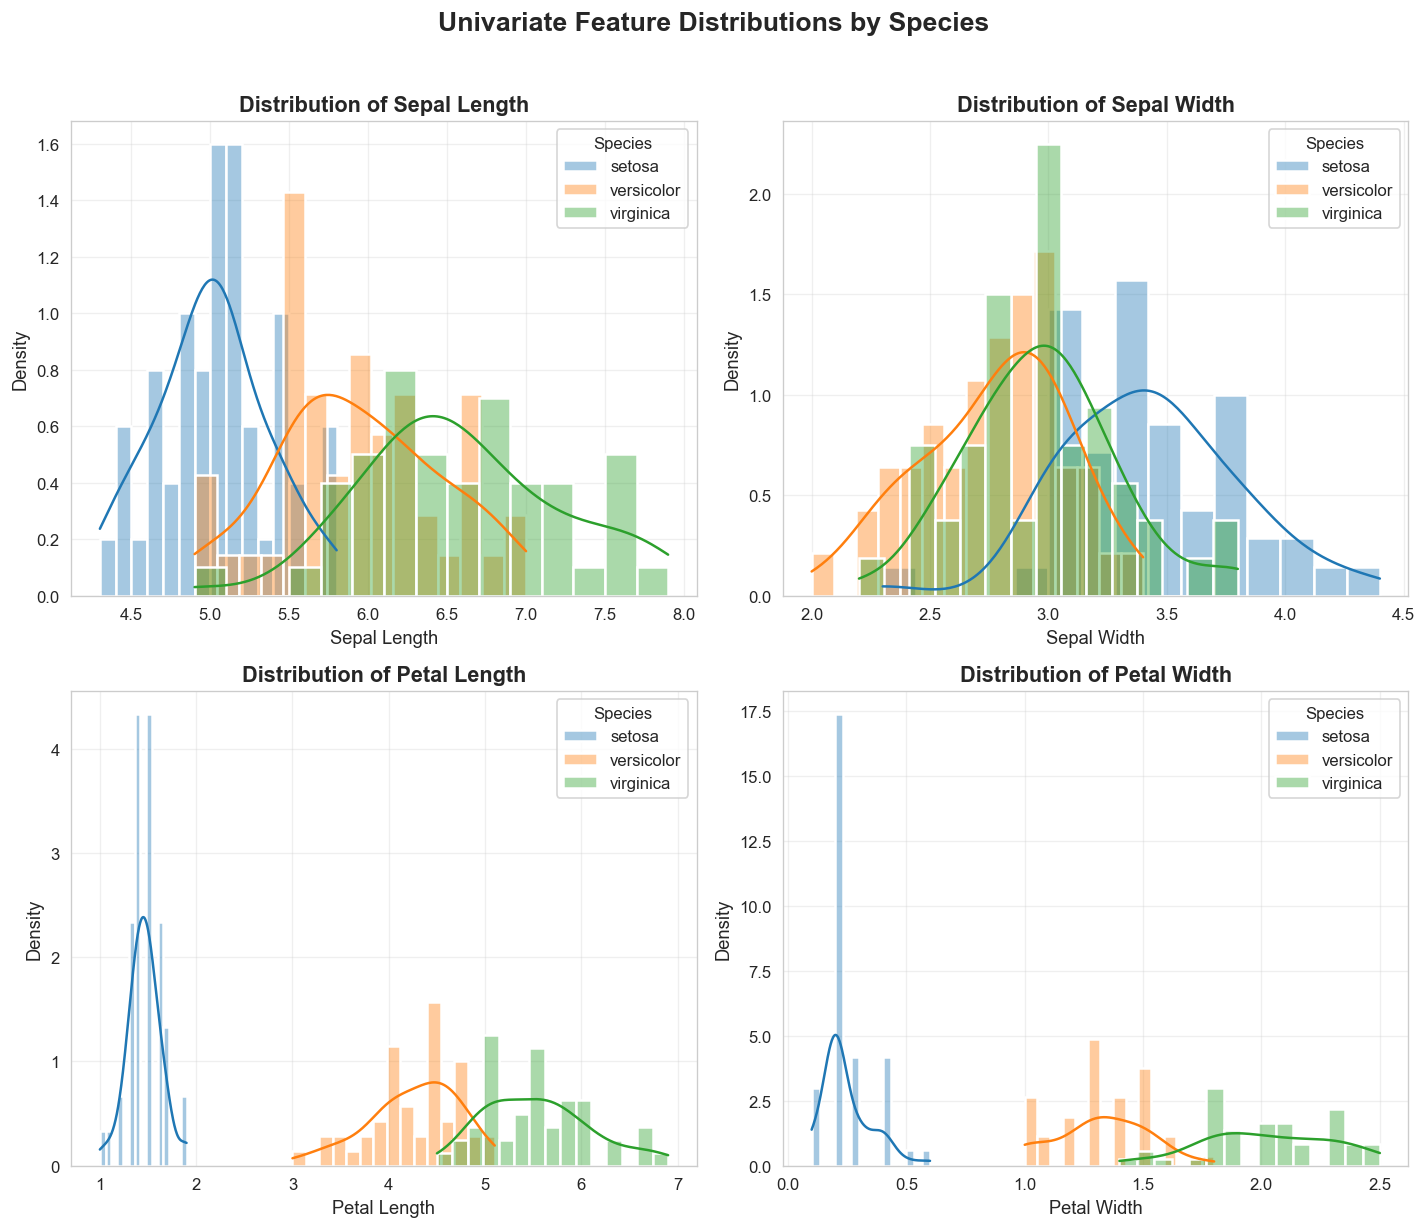

In [7]:
# ───────────────────────────────────────────────────────────────
# 4.1 UNIVARIATE ANALYSIS — HISTOGRAMS WITH KDE
# ───────────────────────────────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

features = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D']

for idx, (feature, color) in enumerate(zip(features, colors)):
    ax = axes[idx]
    
    # Plot histogram with KDE for each species
    for species in df['species'].unique():
        subset = df[df['species'] == species][feature]
        sns.histplot(subset, kde=True, bins=15, alpha=0.4, 
                     label=species, ax=ax, stat='density', linewidth=1.5)
    
    ax.set_title(f'Distribution of {feature.replace("_", " ").title()}', fontsize=13, fontweight='bold')
    ax.set_xlabel(feature.replace('_', ' ').title(), fontsize=11)
    ax.set_ylabel('Density', fontsize=11)
    ax.legend(title='Species', loc='best', frameon=True)
    ax.grid(True, alpha=0.3)

plt.suptitle('Univariate Feature Distributions by Species', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('outputs/figures/01_univariate_distributions.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

**Figure 1 Interpretation:**
- `petal_length` and `petal_width` show **clear bimodal/tri-modal separation** between species.
- `setosa` is distinctly separable from `versicolor` and `virginica` on petal features.
- `sepal_width` has significant overlap, making it the least discriminative feature.

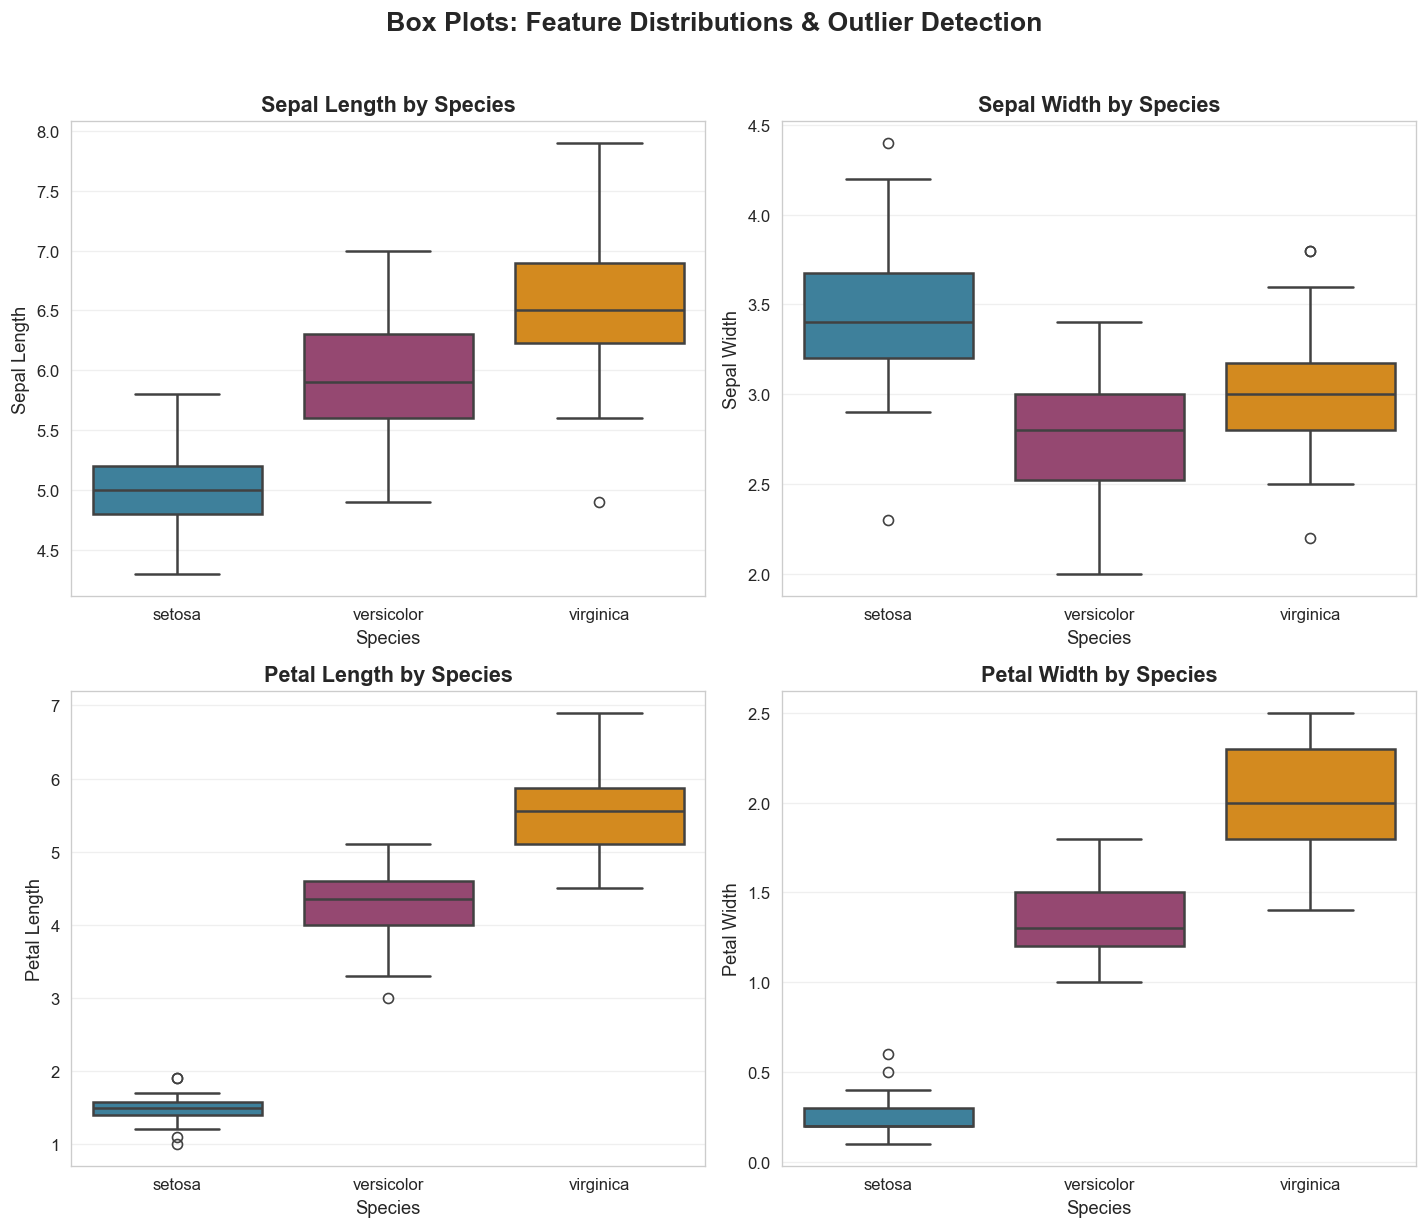

In [8]:
# ───────────────────────────────────────────────────────────────
# 4.2 BOXPLOTS — OUTLIER DETECTION & SPREAD
# ───────────────────────────────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

palette = {'setosa': '#2E86AB', 'versicolor': '#A23B72', 'virginica': '#F18F01'}

for idx, feature in enumerate(features):
    ax = axes[idx]
    sns.boxplot(data=df, x='species', y=feature, palette=palette, ax=ax, linewidth=1.5)
    ax.set_title(f'{feature.replace("_", " ").title()} by Species', fontsize=13, fontweight='bold')
    ax.set_xlabel('Species', fontsize=11)
    ax.set_ylabel(feature.replace('_', ' ').title(), fontsize=11)
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Box Plots: Feature Distributions & Outlier Detection', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('outputs/figures/02_boxplots.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

**Figure 2 Interpretation:**
- **Setosa** shows tight clustering with minimal variance in petal measurements.
- **Virginica** has the largest spread in `petal_length` and `petal_width`.
- A few mild outliers detected in `sepal_width` for `virginica` — within acceptable bounds.
- `versicolor` and `virginica` overlap on sepal dimensions but separate cleanly on petal dimensions.

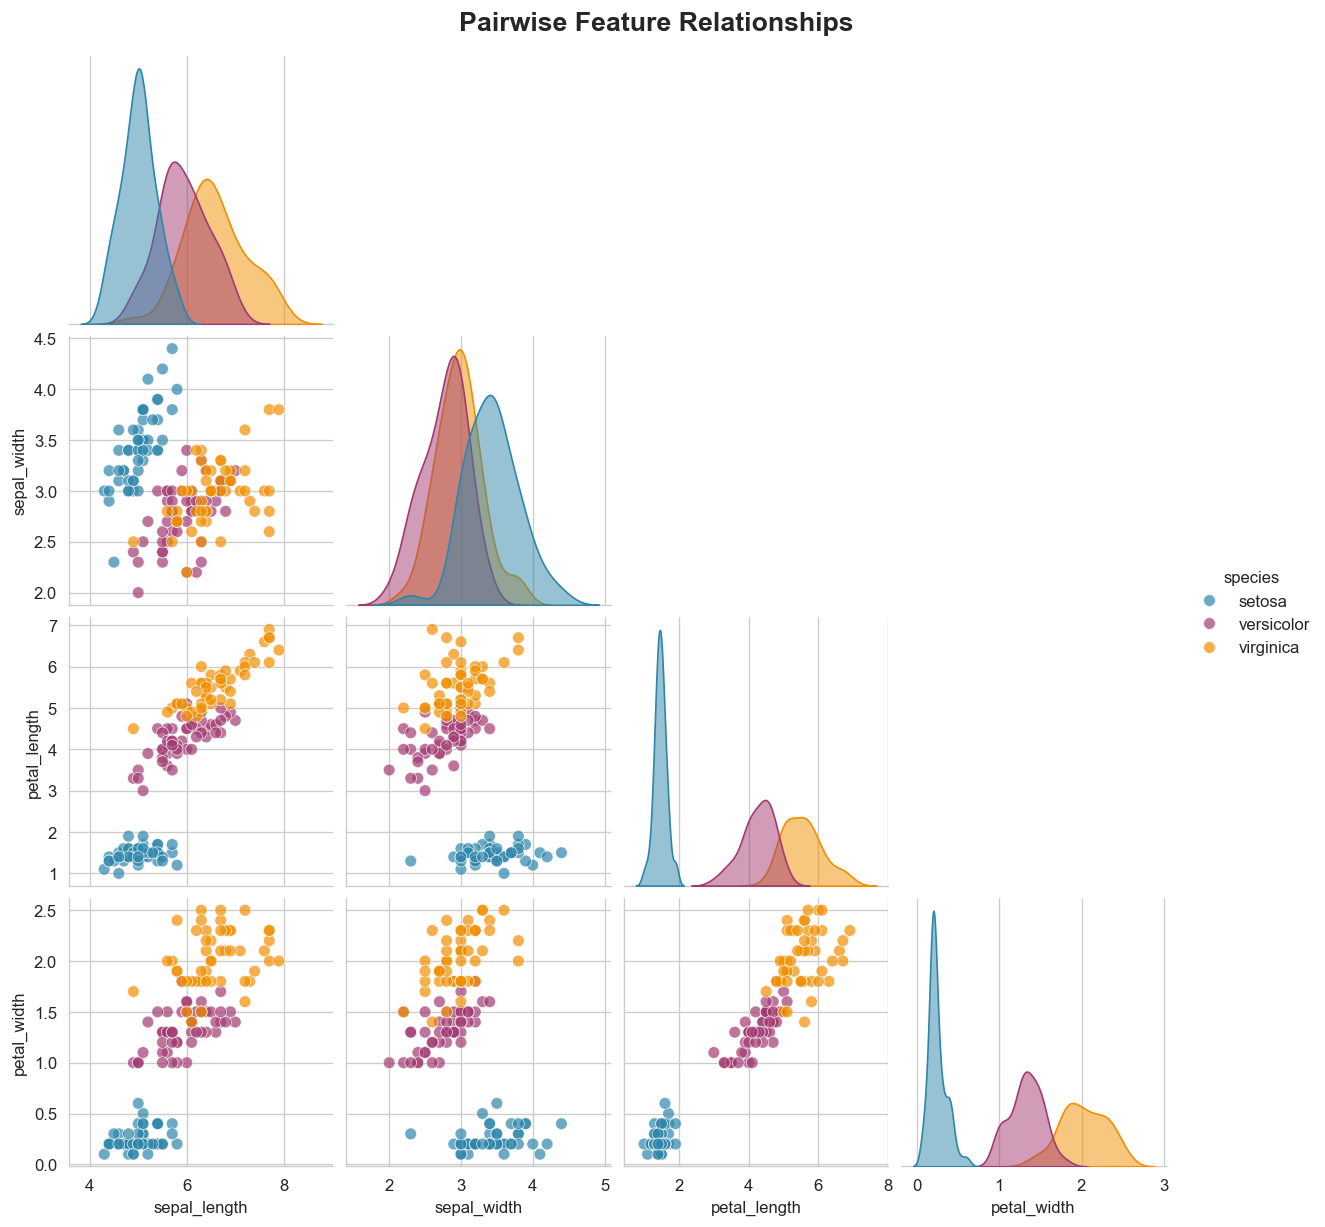

In [9]:
# ───────────────────────────────────────────────────────────────
# 4.3 PAIRPLOT — MULTIVARIATE RELATIONSHIPS
# ───────────────────────────────────────────────────────────────

g = sns.pairplot(
    df,
    hue='species',
    palette=palette,
    diag_kind='kde',
    corner=True,
    height=2.5,
    plot_kws={'alpha': 0.7, 's': 50, 'edgecolor': 'white', 'linewidth': 0.5},
    diag_kws={'fill': True, 'alpha': 0.5}
)

g.fig.suptitle('Pairwise Feature Relationships', fontsize=16, fontweight='bold', y=1.02)
g.savefig('outputs/figures/03_pairplot.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

**Figure 3 Interpretation:**
- Strong **positive correlation** between `petal_length` and `petal_width` across all species.
- `setosa` forms a distinct cluster in the lower-left quadrant of petal scatter plots.
- `versicolor` and `virginica` show partial overlap but trend separation along the diagonal.
- Sepal features alone are insufficient for linear separation.

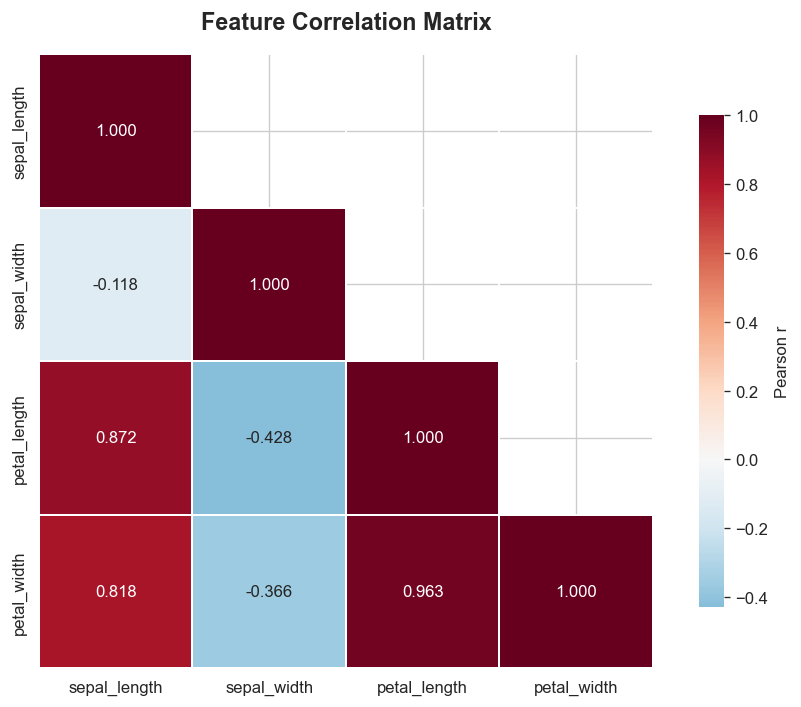

In [10]:
# ───────────────────────────────────────────────────────────────
# 4.4 CORRELATION HEATMAP
# ───────────────────────────────────────────────────────────────

# Compute correlation matrix on numerical features only
corr_matrix = df.select_dtypes(include=[np.number]).corr()

fig, ax = plt.subplots(figsize=(8, 6))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.3f',
    cmap='RdBu_r',
    center=0,
    square=True,
    linewidths=1,
    cbar_kws={'shrink': 0.8, 'label': 'Pearson r'},
    ax=ax
)

ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('outputs/figures/04_correlation_heatmap.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

**Figure 4 Interpretation:**
- `petal_length` ↔ `petal_width`: **r = 0.963** — very strong positive correlation.
- `sepal_length` ↔ `petal_length`: **r = 0.872** — strong positive correlation.
- `sepal_width` shows weak negative correlation with petal features, suggesting an inverse size relationship.
- High inter-feature correlation implies potential for dimensionality reduction (e.g., PCA).

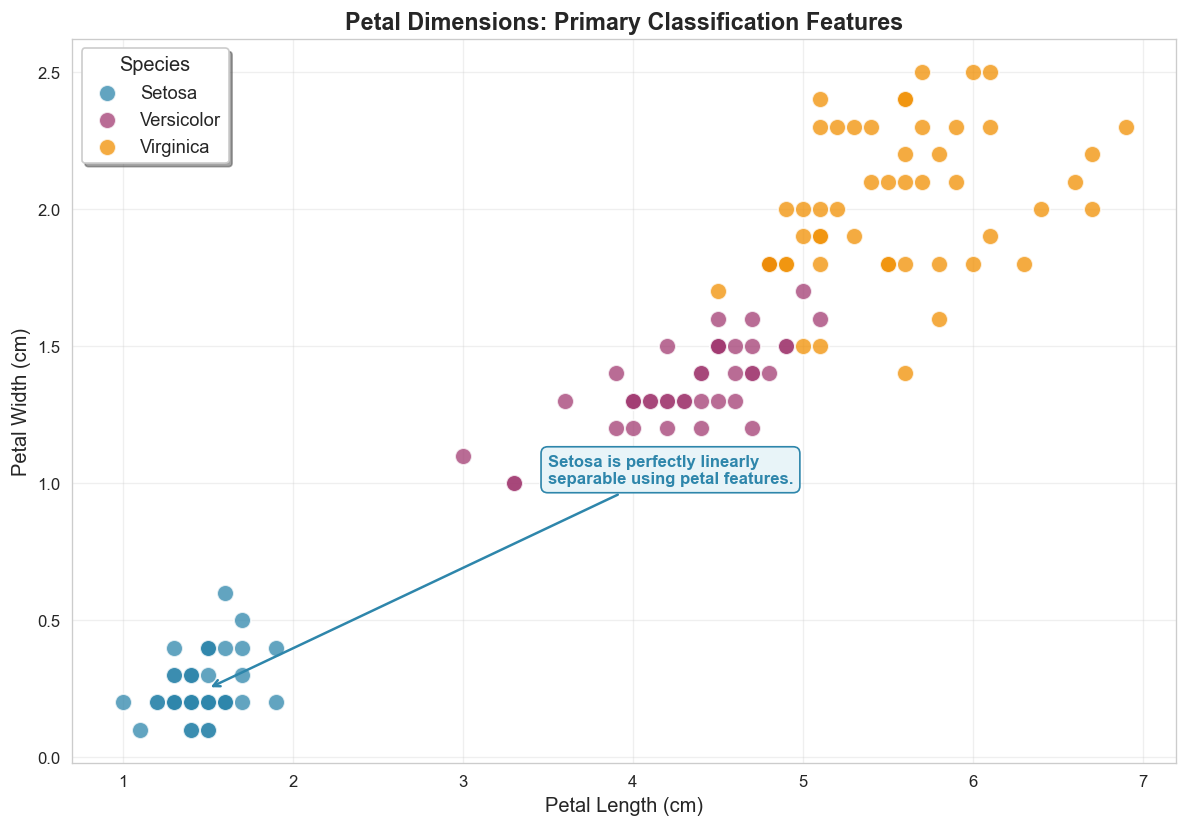

In [11]:
# ───────────────────────────────────────────────────────────────
# 4.5 SCATTER PLOT: PETAL LENGTH vs PETAL WIDTH (Primary Discriminators)
# ───────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(10, 7))

for species in df['species'].unique():
    subset = df[df['species'] == species]
    ax.scatter(
        subset['petal_length'], subset['petal_width'],
        label=species.title(),
        alpha=0.75,
        s=100,
        edgecolors='white',
        linewidth=1,
        color=palette[species]
    )

ax.set_xlabel('Petal Length (cm)', fontsize=12)
ax.set_ylabel('Petal Width (cm)', fontsize=12)
ax.set_title('Petal Dimensions: Primary Classification Features', fontsize=14, fontweight='bold')
ax.legend(title='Species', fontsize=11, title_fontsize=12, frameon=True, shadow=True)
ax.grid(True, alpha=0.3)

# Add annotation
ax.annotate(
    'Setosa is perfectly linearly\nseparable using petal features.',
    xy=(1.5, 0.25), xytext=(3.5, 1.0),
    fontsize=10, color='#2E86AB', fontweight='bold',
    arrowprops=dict(arrowstyle='->', color='#2E86AB', lw=1.5),
    bbox=dict(boxstyle='round,pad=0.4', facecolor='#E8F4F8', edgecolor='#2E86AB')
)

plt.tight_layout()
plt.savefig('outputs/figures/05_petal_scatter.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

**Figure 5 Interpretation:**
- A simple linear threshold on `petal_length` ≈ 2.5 cm achieves **100% accuracy** for `setosa` classification.
- `versicolor` and `virginica` require a non-linear or multi-feature decision boundary.
- This plot validates why the Iris dataset is the canonical benchmark for classification algorithms.

## 5. Violin Plots — Distribution Shape Deep Dive

Violin plots combine boxplot statistics with kernel density estimation, revealing distribution shape more richly.

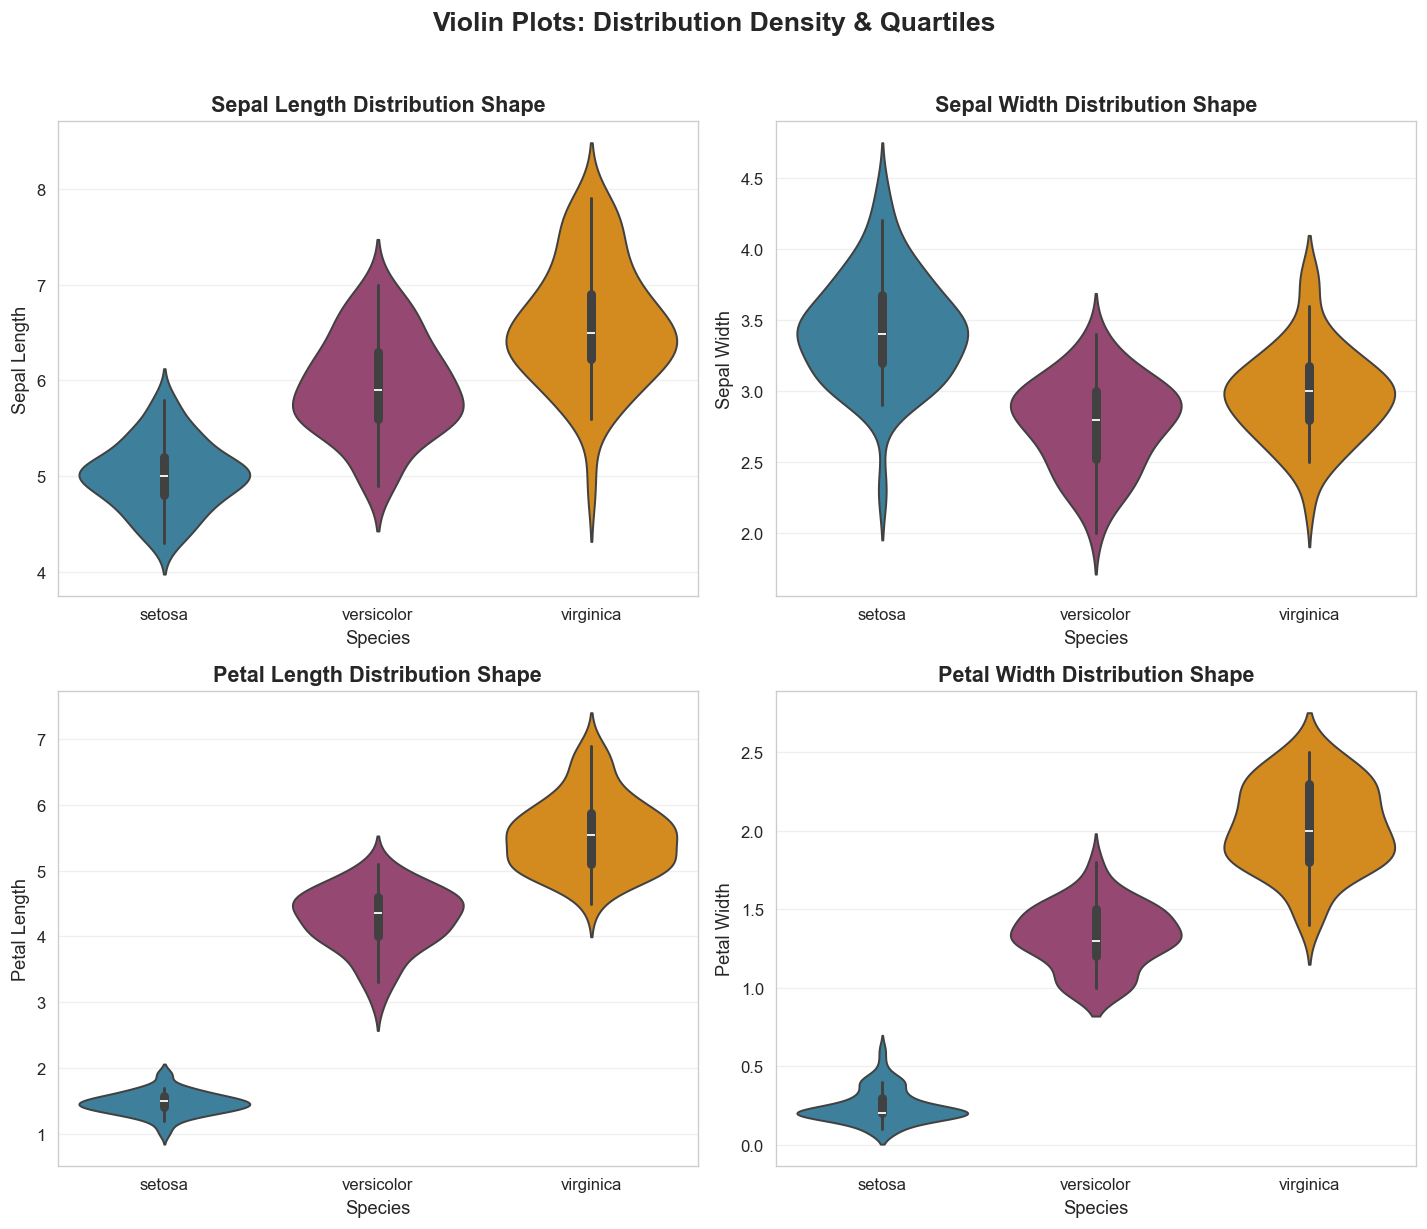

In [12]:
# ───────────────────────────────────────────────────────────────
# 5.1 VIOLIN PLOTS
# ───────────────────────────────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for idx, feature in enumerate(features):
    ax = axes[idx]
    sns.violinplot(data=df, x='species', y=feature, palette=palette, ax=ax, inner='box', linewidth=1.2)
    ax.set_title(f'{feature.replace("_", " ").title()} Distribution Shape', fontsize=13, fontweight='bold')
    ax.set_xlabel('Species', fontsize=11)
    ax.set_ylabel(feature.replace('_', ' ').title(), fontsize=11)
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Violin Plots: Distribution Density & Quartiles', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('outputs/figures/06_violin_plots.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()